# From Poisson counts to a negative binomial

A relapse trial counts the relapses of each patient over a window and compares the counts of
two arms. This notebook builds the count distribution from the bottom up: a cohort in which
every patient carries the same onset rate gives Poisson counts, a cohort whose rates are
spread over a gamma distribution gives negative binomial counts of dispersion 1 / k, and a
cohort whose rate changes with time inside each patient gives over-dispersed counts of its
own. The last section separates the two sources, which no single count can do.

## Provenance

**No clinical data are used in this notebook.** Every cohort below is simulated with the
alternating renewal engine of `msrelapse.renewal`, which draws durations from their target
means and has no potential behind it. The two mean durations it is aimed at are the ones the
article prints, read from `msrelapse.PAPER`; everything else, the window and the spread of
the rates, is chosen here and named as such.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import msrelapse
from msrelapse import plots

# Every random step of this notebook is drawn from this one seed.
SEED = 20130910
# Patients per cohort and the counting window, in weeks. Neither is from the
# article: five years of follow up puts a few relapses on each patient, which is
# what a count distribution needs to be visible at all.
N_PATIENTS = 400
WINDOW = 260.0

lam, mu = msrelapse.rates_from_means(
    msrelapse.PAPER.tau_health_cohort_weeks.value,
    msrelapse.PAPER.tau_no_health_cohort_weeks.value,
)
onset_rate = msrelapse.effective_onset_rate(lam, mu)
print(f"remission ends at {lam:.5f} per week, relapses end at {mu:.5f} per week")
print(f"relapse onsets arrive at {onset_rate:.5f} per week, {onset_rate * WINDOW:.2f} per window")

remission ends at 0.01000 per week, relapses end at 0.23256 per week
relapse onsets arrive at 0.00959 per week, 2.49 per window


## One rate for everyone gives Poisson counts

The onsets of an alternating renewal record arrive at `1 / (tau_health + tau_relapse)`, and
over a window many times longer than one cycle their count is close to Poisson. It is not
exactly Poisson: no relapse can start while the previous one is still running, so the counts
are slightly under-dispersed, and the fit below reports a dispersion of zero rather than a
positive one.

mean 2.428, variance 2.200
dispersion 0.0000, p value against Poisson 1.000


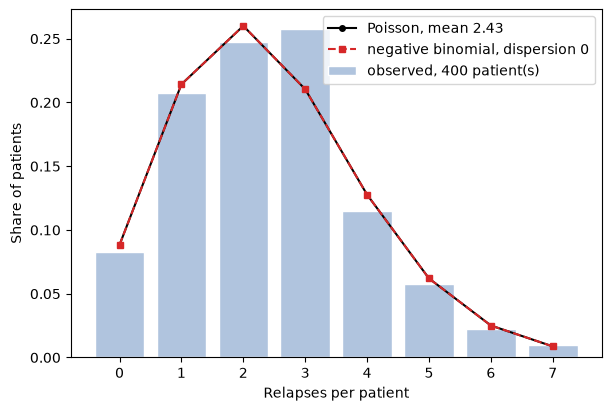

In [2]:
fixed_events = msrelapse.alternating_renewal(
    lam, mu, WINDOW, n=N_PATIENTS, rng=SEED, start_state="health"
)
fixed_counts = msrelapse.relapse_counts(fixed_events)
fixed_fit = msrelapse.fit_nb_counts(fixed_counts)

print(f"mean {fixed_fit.mean:.3f}, variance {float(np.var(fixed_counts)):.3f}")
print(f"dispersion {fixed_fit.dispersion:.4f}, p value against Poisson {fixed_fit.p_value:.3f}")
plots.fig_poisson_to_nb(fixed_counts)
plt.show()

## A gamma spread of rates gives a negative binomial

Now give each patient their own onset rate, drawn from a gamma distribution of shape k and
scale theta. The counts are then Poisson given the rate and negative binomial once the rate
is averaged out, with mean `k theta T` and dispersion `1 / k`. The shape below is chosen to
give a strongly spread cohort while keeping its mean rate at the rate above.

mean 2.442, variance 6.687
dispersion 0.671, 95% interval 0.526 to 0.855
p value against Poisson 2.3e-54


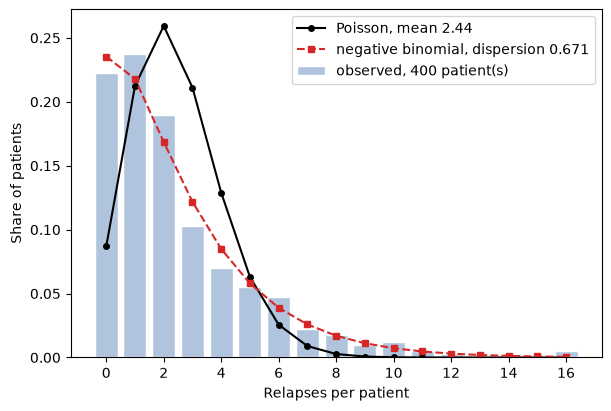

In [3]:
K = 1.5
theta = onset_rate / K
rates = msrelapse.gamma_rates(K, theta, N_PATIENTS, rng=SEED)


def remission_rate(onset, relapse_rate):
    """Return the remission rate whose long run onset rate is `onset`.

    One onset costs one remission and one relapse, so an onset rate is reachable
    only below the rate at which relapses end. A reader who raises K, or the
    number of patients, draws from further out in the tail of the gamma and can
    walk into that limit, which is what the check below reports.
    """
    highest = float(np.max(onset))
    if highest >= relapse_rate:
        raise ValueError(
            f"an onset rate of {highest:.4g} per week is out of reach with relapses "
            f"ending at {relapse_rate:.4g} per week: one onset costs one remission and "
            f"one relapse, so the onset rate stays below the relapse rate"
        )
    return 1.0 / (1.0 / onset - 1.0 / relapse_rate)


gamma_events = msrelapse.alternating_renewal(
    remission_rate(rates, mu), mu, WINDOW, n=N_PATIENTS, rng=SEED + 1, start_state="health"
)
gamma_counts = msrelapse.relapse_counts(gamma_events)
gamma_fit = msrelapse.fit_nb_counts(gamma_counts)

print(f"mean {gamma_fit.mean:.3f}, variance {float(np.var(gamma_counts)):.3f}")
low, high = gamma_fit.dispersion_ci
print(f"dispersion {gamma_fit.dispersion:.3f}, 95% interval {low:.3f} to {high:.3f}")
print(f"p value against Poisson {gamma_fit.p_value:.3g}")
plots.fig_poisson_to_nb(gamma_counts)
plt.show()

## Two sources of over-dispersion, and how to tell them apart

Counts spread wider than a Poisson for two quite different reasons. Patients may differ from
one another, which is the gamma mixing above and persists for as long as the patient is
followed. Or a patient's own rate may change with time, which spreads the counts of a short
window while leaving the count of a long one alone. The third cohort below has no spread
between patients at all: every patient carries the same rate on average, but half of them run
fast in the first half of follow up and slow in the second, and half the other way round.

In [4]:
SWING = 0.6
half = WINDOW / 2.0

swing_generator = np.random.default_rng(SEED + 2)
swing = swing_generator.choice([-SWING, SWING], size=N_PATIENTS)
first_events = msrelapse.alternating_renewal(
    remission_rate(onset_rate * (1.0 + swing), mu),
    mu,
    half,
    n=N_PATIENTS,
    rng=SEED + 3,
    start_state="health",
)
second_events = msrelapse.alternating_renewal(
    remission_rate(onset_rate * (1.0 - swing), mu),
    mu,
    half,
    n=N_PATIENTS,
    rng=SEED + 4,
    start_state="health",
)
varying_counts = msrelapse.relapse_counts(first_events) + msrelapse.relapse_counts(second_events)
print(f"mean {float(varying_counts.mean()):.3f}, variance {float(np.var(varying_counts)):.3f}")

mean 2.558, variance 2.587


In [5]:
halves = {
    "one rate for everyone": (
        msrelapse.relapse_counts(fixed_events, window=half),
        fixed_counts - msrelapse.relapse_counts(fixed_events, window=half),
    ),
    "gamma spread between patients": (
        msrelapse.relapse_counts(gamma_events, window=half),
        gamma_counts - msrelapse.relapse_counts(gamma_events, window=half),
    ),
    "rate varying inside each patient": (
        msrelapse.relapse_counts(first_events),
        msrelapse.relapse_counts(second_events),
    ),
}

source_rows = []
for label, (first_half, second_half) in halves.items():
    whole = first_half + second_half
    source_rows.append(
        (
            label,
            msrelapse.fit_nb_counts(whole).dispersion,
            msrelapse.fit_nb_counts(first_half).dispersion,
            float(np.corrcoef(first_half, second_half)[0, 1]),
        )
    )

sources = pd.DataFrame(
    source_rows,
    columns=["cohort", "dispersion_whole_window", "dispersion_first_half", "correlation_halves"],
)
sources

,cohort,dispersion_whole_window,dispersion_first_half,correlation_halves
0,one rate for everyone,0.000000,0.000000,-0.015574
1,gamma spread between patients,0.670559,0.560414,0.520112
2,rate varying inside each patient,0.004827,0.328171,-0.261347


The whole window tells the first two cohorts apart and says nothing about the third, whose
counts are as Poisson as the cohort that has one rate for everyone: every patient has the
same expected total, however that total is spread over the two halves. Read on a half window
the third cohort is over-dispersed as well, and the two sources then part company in the
correlation between the halves. A spread between patients makes a patient who relapsed often
in the first half relapse often in the second, so the correlation is positive; a rate that
swings inside the patient does the opposite.

## What the two cohorts do to the chance of staying relapse free

The same distinction shows in the share of patients who reach the end of a window with no
relapse at all. With one rate for everyone that share is `exp(-lam T)`; with rates spread
over a gamma it is `(1 + theta T)` raised to minus k, which falls more slowly because the
patients with a low rate dominate the survivors.

Both curves are laws of the waiting time to the first relapse, so the rate they carry is the
rate at which a remission ends and not the long run onset rate of the sections above: the two
differ by the few percent of each cycle that is spent in relapse, during which no new relapse
can start. The curve of the one rate cohort is drawn at that remission rate, which is exactly
what the engine draws the first waiting time from. The gamma curve keeps the spread of onset
rates the cohort was built with, which leaves it a few percent off the law its points follow,
far inside the scatter of 400 patients.

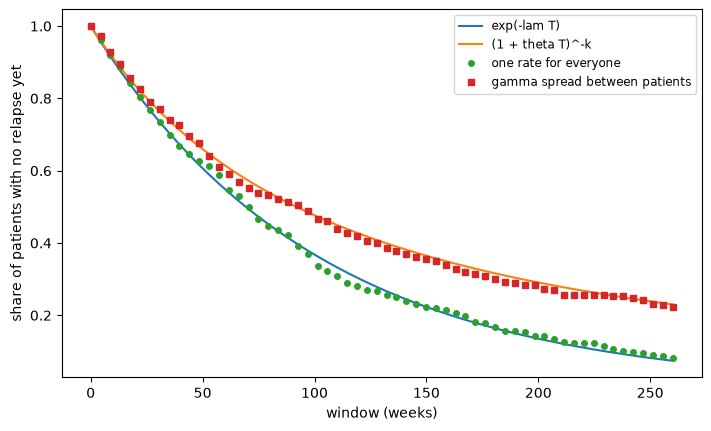

In [6]:
def first_onset_survival(events, grid):
    """Return the share of patients whose first relapse comes after each window."""
    first = events.groupby("patient_id", sort=True)["relapse_onset"].min()
    onsets = first.to_numpy(dtype=float)
    # A patient who never relapsed has a missing onset, which compares False
    # against every window and so counts as still free of relapse throughout.
    return np.array([float(np.mean(~(onsets <= point))) for point in grid])


grid = np.linspace(0.0, WINDOW, 60)
panel = plt.subplots(figsize=(7.0, 4.2), layout="constrained")[1]
panel.plot(grid, msrelapse.relapse_free_curve(grid, lam=lam), label="exp(-lam T)")
panel.plot(grid, msrelapse.relapse_free_curve(grid, k=K, theta=theta), label="(1 + theta T)^-k")
panel.plot(
    grid,
    first_onset_survival(fixed_events, grid),
    linestyle="none",
    marker="o",
    markersize=4,
    label="one rate for everyone",
)
panel.plot(
    grid,
    first_onset_survival(gamma_events, grid),
    linestyle="none",
    marker="s",
    markersize=4,
    label="gamma spread between patients",
)
panel.set_xlabel("window (weeks)")
panel.set_ylabel("share of patients with no relapse yet")
panel.legend(fontsize="small")
plt.show()

## The mapping, predicted and fitted

`nb_from_gamma` turns the two parameters of the rate distribution into the two moments of the
count distribution. The table puts what it predicts beside what the counts of the simulated
cohort give back.

In [7]:
predicted_mean, predicted_dispersion = msrelapse.nb_from_gamma(K, theta, WINDOW)
mapping = pd.DataFrame(
    [
        ("mean count", predicted_mean, gamma_fit.mean),
        ("dispersion", predicted_dispersion, gamma_fit.dispersion),
    ],
    columns=["quantity", "nb_from_gamma", "fit_nb_counts"],
)
ci_low, ci_high = gamma_fit.dispersion_ci
print(f"the fitted dispersion carries the 95% interval {ci_low:.3f} to {ci_high:.3f}")
mapping

the fitted dispersion carries the 95% interval 0.526 to 0.855


,quantity,nb_from_gamma,fit_nb_counts
0,mean count,2.492809,2.442500
1,dispersion,0.666667,0.670559


## How to cite

This notebook reproduces the article below, and the package it uses carries the same
reference on every result object. The text is what `msrelapse.citation()` prints.

```text
Bordi I, Umeton R, Ricigliano VAG, Annibali V, Mechelli R, Ristori G, Grassi F, Salvetti M, Sutera A. A mechanistic, stochastic model helps understand multiple sclerosis course and pathogenesis. International Journal of Genomics. 2013;2013:910321. doi:10.1155/2013/910321.

@article{bordi2013mechanistic,
  author    = {Bordi, Isabella and Umeton, Renato and Ricigliano, Vito A. G. and Annibali, Viviana and Mechelli, Rosella and Ristori, Giovanni and Grassi, Francesca and Salvetti, Marco and Sutera, Alfonso},
  title     = {A mechanistic, stochastic model helps understand multiple sclerosis course and pathogenesis},
  journal   = {International Journal of Genomics},
  volume    = {2013},
  pages     = {910321},
  year      = {2013},
  doi       = {10.1155/2013/910321},
  publisher = {Wiley}
}

@software{msrelapse,
  author  = {Umeton, Renato},
  title   = {msrelapse: a reference implementation of the Bordi et al. 2013 double well model of multiple sclerosis},
  year    = {2026},
  version = {0.1.0},
  url     = {https://github.com/renato-umeton/multiple-sclerosis-modeling-bordi},
  note    = {This software reproduces the article, doi 10.1155/2013/910321, which is the reference to cite.}
}
```